In [1]:
import sys
import os

# Obtém o caminho do diretório-pai do diretório atual (notebooks/)
# Isso deve ser o diretório raiz do seu projeto, onde 'src' está.
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Adiciona o diretório raiz ao caminho de busca do Python
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Caminho do projeto adicionado ao sys.path: {project_root}")

Caminho do projeto adicionado ao sys.path: /home/igorreis/Documentos/Python Projects/chess-data-coach


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, 
    classification_report
)

# Importa suas funções existentes
from src.services.analysis import prepare_logistic_regression, train_logistic_regression_model
df = pd.read_csv("/home/igorreis/Documentos/Python Projects/chess-data-coach/notebooks/chess_report_for_logistic_regression.csv")

In [3]:
X, y = prepare_logistic_regression(df)

In [4]:
X.shape, y.shape

((1000, 9), (1000,))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# Garante que todas as colunas sejam numéricas
X_train_clean = X_train.apply(pd.to_numeric, errors="coerce")
X_train_clean = X_train_clean.astype(float) # Necessário pois o código acima transforma em bool

# Remove colunas inteiras preenchidas com NaN (caso raro)
X_train_clean = X_train_clean.dropna(axis=1, how='all')

# Remove linhas com NaN restantes
mask = ~X_train_clean.isna().any(axis=1)
X_train_clean = X_train_clean[mask]
y_train_clean = y_train[mask]

In [7]:
# Limpa X_test da mesma forma que X_train
X_test_clean = X_test.apply(pd.to_numeric, errors="coerce")

# Converte booleanos para int
bool_cols_test = X_test_clean.select_dtypes(include='bool').columns
X_test_clean[bool_cols_test] = X_test_clean[bool_cols_test].astype(int)

# Remove linhas com NaN (mantendo alinhamento com y_test)
mask_test = ~X_test_clean.isna().any(axis=1)
X_test_clean = X_test_clean[mask_test]
y_test_clean = y_test[mask_test]


In [8]:
# Adiciona intercepto
X_train_sm = sm.add_constant(X_train_clean)

# Ajusta modelo Logit
logit_model = sm.Logit(y_train_clean, X_train_sm)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.673255
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  800
Model:                          Logit   Df Residuals:                      791
Method:                           MLE   Df Model:                            8
Date:                Sat, 06 Dec 2025   Pseudo R-squ.:                 0.02868
Time:                        15:40:54   Log-Likelihood:                -538.60
converged:                       True   LL-Null:                       -554.51
Covariance Type:            nonrobust   LLR p-value:                 0.0001008
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                  0.3010        nan    

In [9]:
coef = result.params
se = result.bse
pvals = result.pvalues
ci = result.conf_int()
odds = np.exp(coef)
ci_or = np.exp(ci)

summary_table = pd.DataFrame({
    "coef": coef,
    "std_error": se,
    "p_value": pvals,
    "odds_ratio": odds,
    "ci_lower_95": ci_or[0],
    "ci_upper_95": ci_or[1]
})

print(summary_table)

                                        coef  std_error   p_value  odds_ratio  \
const                               0.301014        NaN       NaN    1.351229   
rating_difference                   0.005119   0.001249  0.000041    1.005132   
full_moves                         -0.015040   0.004759  0.001577    0.985073   
is_white                            0.204925   0.189215  0.278796    1.227433   
opening_group_French Defense       -0.030129        NaN       NaN    0.970321   
opening_group_Italian Game          0.049496        NaN       NaN    1.050741   
opening_group_King's Pawn Game      0.086212        NaN       NaN    1.090038   
opening_group_Other                 0.037228        NaN       NaN    1.037930   
opening_group_Queen's Pawn Game    -0.163452        NaN       NaN    0.849207   
opening_group_Scandinavian Defense  0.321659        NaN       NaN    1.379415   

                                    ci_lower_95  ci_upper_95  
const                                       N

In [10]:
# Probabilidades preditas no conjunto de teste
X_test_sm = sm.add_constant(X_test_clean)

y_prob = result.predict(X_test_sm)
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test_clean, y_prob)
print("AUC:", auc)

AUC: 0.5366687066503468


In [11]:
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusão:\n", cm)

Matriz de confusão:
 [[65 49]
 [42 44]]


In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.57      0.59       114
           1       0.47      0.51      0.49        86

    accuracy                           0.55       200
   macro avg       0.54      0.54      0.54       200
weighted avg       0.55      0.55      0.55       200



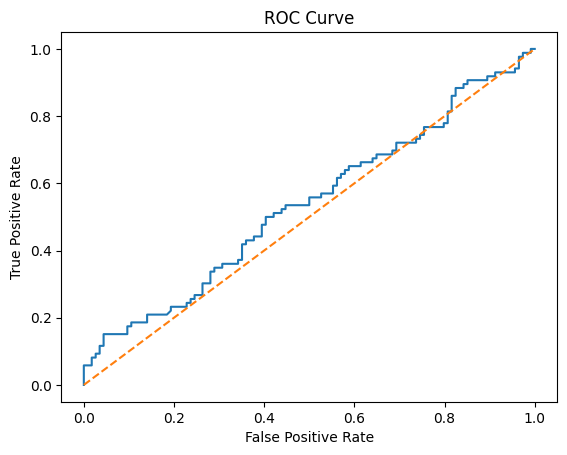

In [13]:
import matplotlib.pyplot as plt

fpr, tpr, thr = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [14]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_clean),
    columns=X_train_clean.columns,
    index=X_train_clean.index     # <- ESSENCIAL
)

X_train_scaled = sm.add_constant(X_train_scaled)

logit_std = sm.Logit(y_train_clean, X_train_scaled).fit()
print(logit_std.summary())

Optimization terminated successfully.
         Current function value: 0.673255
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  800
Model:                          Logit   Df Residuals:                      791
Method:                           MLE   Df Model:                            8
Date:                Sat, 06 Dec 2025   Pseudo R-squ.:                 0.02868
Time:                        15:40:54   Log-Likelihood:                -538.60
converged:                       True   LL-Null:                       -554.51
Covariance Type:            nonrobust   LLR p-value:                 0.0001008
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
const                                  0.0107      0.072    

In [15]:
coef_std = logit_std.params
se_std = logit_std.bse
pvals_std = logit_std.pvalues

summary_std = pd.DataFrame({
    "coef_standardized": coef_std,
    "std_error": se_std,
    "p_value": pvals_std
})

summary_std

,coef_standardized,std_error,p_value
const,0.010693,0.072138,0.882160
rating_difference,0.303047,0.073932,0.000041
full_moves,-0.231005,0.073100,0.001577
is_white,0.102447,0.094593,0.278796
opening_group_French Defense,-0.017802,NaN,NaN
opening_group_Italian Game,-0.001374,NaN,NaN
opening_group_King's Pawn Game,0.014556,NaN,NaN
opening_group_Other,-0.008637,NaN,NaN
opening_group_Queen's Pawn Game,-0.055182,NaN,NaN
opening_group_Scandinavian Defense,0.064637,NaN,NaN


In [16]:
from sklearn.utils import resample

boot_aucs = []
for i in range(1000):
    idx = np.random.choice(len(y_test), len(y_test), replace=True)
    y_boot = y_test.iloc[idx]
    prob_boot = y_prob.iloc[idx]
    
    try:
        boot_aucs.append(roc_auc_score(y_boot, prob_boot))
    except:
        pass

ci_95 = np.percentile(boot_aucs, [2.5, 97.5])
print("AUC CI 95%:", ci_95)

AUC CI 95%: [0.45460962 0.61323989]
